# 🚜 Tractor Warehouse — Spare Parts Classification
### K-Means Clustering: Fast Moving | Slow Moving | Rare Moving
---

## 1. Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2. Load & Explore the Data

In [11]:
# ─── CHANGE THIS PATH to your CSV file ───────────────────────────────────────
CSV_PATH = r'data/usage_log.csv'
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH, parse_dates=['date'])

print('='*55)
print('        DATASET OVERVIEW')
print('='*55)
print(f'  Total records   : {len(df):,}')
print(f'  Unique parts    : {df["part_id"].nunique()}')
print(f'  Date range      : {df["date"].min().date()}  →  {df["date"].max().date()}')
print(f'  Months covered  : {((df["date"].max() - df["date"].min()).days // 30)}')
print('='*55)
print()
print('First 5 rows:')
df.head()

        DATASET OVERVIEW
  Total records   : 3,195
  Unique parts    : 30
  Date range      : 2026-01-01  →  2026-06-30
  Months covered  : 6

First 5 rows:


,part_id,date,quantity
0,BRK001,2026-01-01,5
1,BRK002,2026-01-01,3
2,ELE002,2026-01-01,4
3,ENG001,2026-01-01,5
4,ENG002,2026-01-01,3


## 3. Feature Engineering
We derive meaningful features per part for clustering.

In [12]:
# ── Calculate number of active months in the dataset ──
date_range_days = (df['date'].max() - df['date'].min()).days + 1
num_months = max(date_range_days / 30, 1)

# ── Per-day aggregation to find daily quantities ──
daily = df.groupby(['part_id', 'date'])['quantity'].sum().reset_index()

# ── Feature table per part ──
features = daily.groupby('part_id').agg(
    total_qty        = ('quantity', 'sum'),
    avg_daily_qty    = ('quantity', 'mean'),    # avg sold on days it WAS sold
    max_single_day   = ('quantity', 'max'),
    days_with_sales  = ('quantity', 'count'),   # number of unique sale days
).reset_index()

# Sales frequency: how many days per month (on average) does this part sell?
features['days_per_month'] = features['days_with_sales'] / num_months

# Monthly throughput
features['monthly_qty'] = features['total_qty'] / num_months

print('Feature table (first 10 parts):')
print(features.head(10).to_string(index=False))

Feature table (first 10 parts):
part_id  total_qty  avg_daily_qty  max_single_day  days_with_sales  days_per_month  monthly_qty
 BRK001        948       5.479769               7              173       28.674033   157.127072
 BRK002        663       3.993976               5              166       27.513812   109.889503
 BRK003        133       1.494382               2               89       14.751381    22.044199
 BRK004         11       1.000000               1               11        1.823204     1.823204
 ELE001        456       3.060403               4              149       24.696133    75.580110
 ELE002        457       3.026490               4              151       25.027624    75.745856
 ELE003        100       1.515152               2               66       10.939227    16.574586
 ELE004          9       1.000000               1                9        1.491713     1.491713
 ENG001        604       3.532164               5              171       28.342541   100.110497
 ENG002 

## 4. K-Means Clustering (k=3)

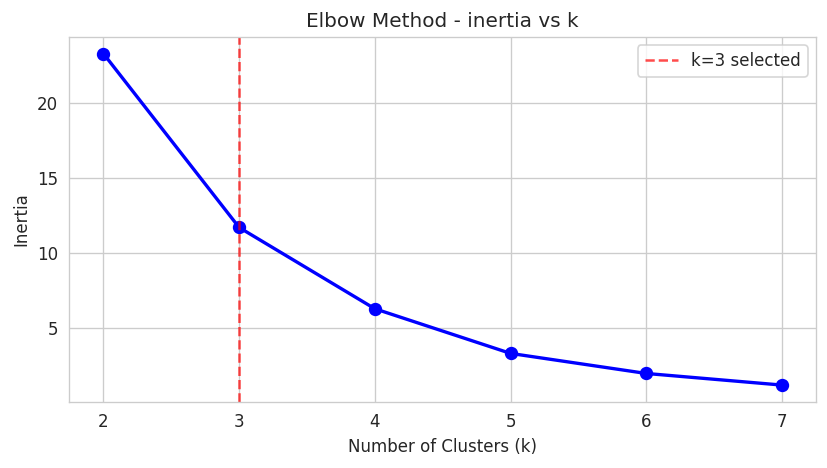

✅ k=3 confirmed.


In [13]:
# ── Select clustering features ──
cluster_cols = ['avg_daily_qty', 'days_per_month', 'monthly_qty', 'max_single_day']
X = features[cluster_cols].values

# ── Standardise so no single feature dominates ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Elbow chart to confirm k=3 is sensible ──
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K_range, inertias, 'bo-',linewidth=2,markersize=7)
plt.axvline(3, color='red', linestyle='--', alpha=0.7, label='k=3 selected')

plt.title("Elbow Method - inertia vs k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.legend()

plt.tight_layout()
plt.savefig('elbow_chart.png', bbox_inches='tight')
plt.show()
print('✅ k=3 confirmed.')

In [ ]:
# ── Final K-Means with k=3 ──
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features['cluster_raw'] = kmeans.fit_predict(X_scaled)

# ── Label clusters by their average monthly_qty (highest = Fast Moving) ──
cluster_means = features.groupby('cluster_raw')['monthly_qty'].mean().sort_values(ascending=False)
label_map = {}
labels_ordered = ['🟢 Fast Moving', '🟡 Slow Moving', '🔴 Rare Moving']
for rank, cluster_id in enumerate(cluster_means.index):
    label_map[cluster_id] = labels_ordered[rank]

features['category'] = features['cluster_raw'].map(label_map)

# ── Summary per category ──
summary = features.groupby('category').agg(
    num_parts       = ('part_id', 'count'),
    avg_daily_qty   = ('avg_daily_qty', 'mean'),
    avg_monthly_qty = ('monthly_qty', 'mean'),
    avg_days_pm     = ('days_per_month', 'mean'),
    max_single_day  = ('max_single_day', 'mean'),
).round(2)

print()
print('='*75)
print('          CLUSTERING SUMMARY')
print('='*75)
print(summary.to_string())
print('='*75)


          CLUSTERING SUMMARY
               num_parts  avg_daily_qty  avg_monthly_qty  avg_days_pm  max_single_day
category                                                                             
🔴 Rare Moving         15           1.41            13.24         8.33             1.8
🟡 Slow Moving         10           3.44            90.91        26.37             4.5
🟢 Fast Moving          5           5.09           143.67        28.18             6.6


## 5. Results — Part-by-Part Classification

In [15]:
result = features[['part_id', 'total_qty', 'avg_daily_qty', 'max_single_day',
                    'days_per_month', 'monthly_qty', 'category']].sort_values(
    'monthly_qty', ascending=False).reset_index(drop=True)

result.columns = ['Part ID', 'Total Qty (6M)', 'Avg Daily Qty',
                  'Max Single Day', 'Sale Days/Month', 'Monthly Avg Qty', 'Category']

result[['Avg Daily Qty', 'Sale Days/Month', 'Monthly Avg Qty']] = \
    result[['Avg Daily Qty', 'Sale Days/Month', 'Monthly Avg Qty']].round(2)

print(result.to_string(index=False))

Part ID  Total Qty (6M)  Avg Daily Qty  Max Single Day  Sale Days/Month  Monthly Avg Qty      Category
 FST003            1059           6.02               8            29.17           175.52 🟢 Fast Moving
 BRK001             948           5.48               7            28.67           157.13 🟢 Fast Moving
 FST002             831           4.98               6            27.68           137.73 🟢 Fast Moving
 ENG002             769           4.45               6            28.67           127.46 🟢 Fast Moving
 HYD003             727           4.52               6            26.69           120.50 🟢 Fast Moving
 MNT002             680           4.07               5            27.68           112.71 🟡 Slow Moving
 ENG003             674           4.08               5            27.35           111.71 🟡 Slow Moving
 BRK002             663           3.99               5            27.51           109.89 🟡 Slow Moving
 ENG001             604           3.53               5            28.34  

## 6. Visualisations

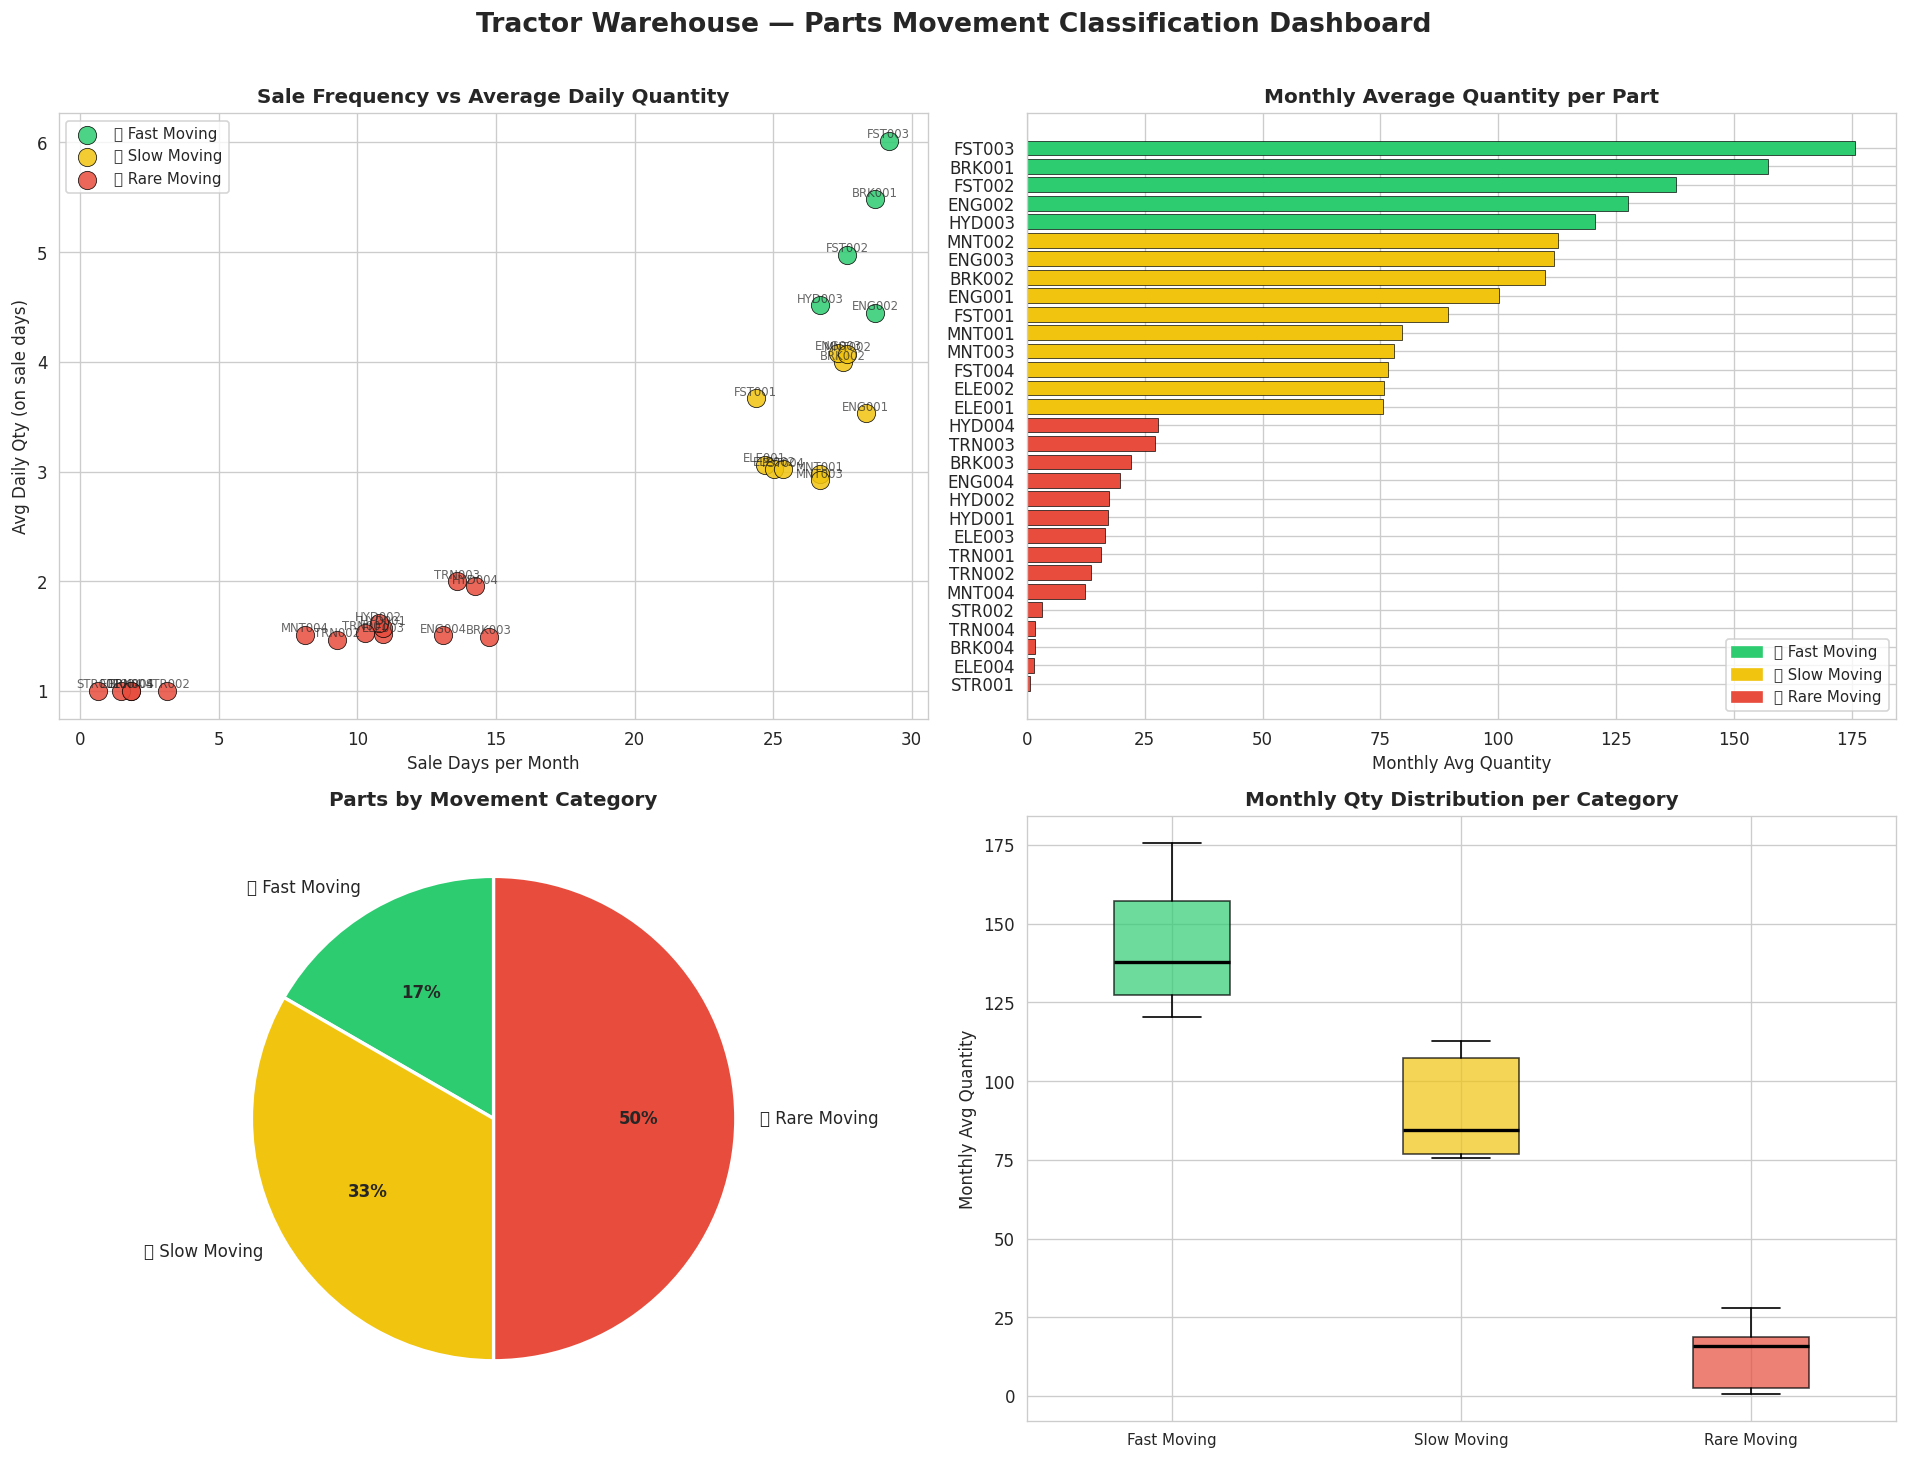

✅ Dashboard saved as classification_dashboard.png


In [16]:
# ── Color palette ──
cat_colors = {
    '🟢 Fast Moving': '#2ecc71',
    '🟡 Slow Moving': '#f1c40f',
    '🔴 Rare Moving': '#e74c3c'
}
color_list = [cat_colors[c] for c in features['category']]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Tractor Warehouse — Parts Movement Classification Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Scatter — Avg Daily Qty vs Sale Days per Month ──
ax1 = axes[0, 0]
for cat, color in cat_colors.items():
    mask = features['category'] == cat
    ax1.scatter(features.loc[mask, 'days_per_month'],
                features.loc[mask, 'avg_daily_qty'],
                c=color, label=cat, s=120, edgecolors='black', linewidth=0.5, alpha=0.85)
    for _, row in features[mask].iterrows():
        ax1.annotate(row['part_id'], (row['days_per_month'], row['avg_daily_qty']),
                     fontsize=7, ha='center', va='bottom', alpha=0.7)
ax1.set_title('Sale Frequency vs Average Daily Quantity', fontweight='bold')
ax1.set_xlabel('Sale Days per Month')
ax1.set_ylabel('Avg Daily Qty (on sale days)')
ax1.legend(fontsize=9)

# ── Plot 2: Horizontal Bar — Monthly Avg Qty per Part ──
ax2 = axes[0, 1]
bar_data = result.sort_values('Monthly Avg Qty', ascending=True)
bar_colors = [cat_colors[c] for c in bar_data['Category']]
bars = ax2.barh(bar_data['Part ID'], bar_data['Monthly Avg Qty'],
                color=bar_colors, edgecolor='black', linewidth=0.4)
ax2.set_title('Monthly Average Quantity per Part', fontweight='bold')
ax2.set_xlabel('Monthly Avg Quantity')
patches = [mpatches.Patch(color=c, label=l) for l, c in cat_colors.items()]
ax2.legend(handles=patches, fontsize=9)

# ── Plot 3: Pie — Category distribution ──
ax3 = axes[1, 0]
cat_counts = features['category'].value_counts()
# Reorder to Fast, Slow, Rare
ordered_cats = [c for c in ['🟢 Fast Moving', '🟡 Slow Moving', '🔴 Rare Moving']
                if c in cat_counts.index]
counts = [cat_counts[c] for c in ordered_cats]
colors = [cat_colors[c] for c in ordered_cats]
wedges, texts, autotexts = ax3.pie(
    counts, labels=ordered_cats, colors=colors,
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
ax3.set_title('Parts by Movement Category', fontweight='bold')

# ── Plot 4: Box — Monthly Qty distribution per category ──
ax4 = axes[1, 1]
for i, cat in enumerate(ordered_cats):
    data = features.loc[features['category'] == cat, 'monthly_qty']
    bp = ax4.boxplot(data, positions=[i], widths=0.4,
                     patch_artist=True,
                     boxprops=dict(facecolor=cat_colors[cat], alpha=0.7),
                     medianprops=dict(color='black', linewidth=2))
ax4.set_xticks(range(len(ordered_cats)))
ax4.set_xticklabels([c.split(' ', 1)[1] for c in ordered_cats], fontsize=9)
ax4.set_title('Monthly Qty Distribution per Category', fontweight='bold')
ax4.set_ylabel('Monthly Avg Quantity')

plt.tight_layout()
plt.savefig('classification_dashboard.png', bbox_inches='tight')
plt.show()
print('✅ Dashboard saved as classification_dashboard.png')

In [17]:
# ── Category-wise part lists ──
print('='*65)
for cat in ['🟢 Fast Moving', '🟡 Slow Moving', '🔴 Rare Moving']:
    parts = result.loc[result['Category'] == cat, 'Part ID'].tolist()
    mean_monthly = result.loc[result['Category'] == cat, 'Monthly Avg Qty'].mean()
    print(f'{cat}')
    print(f'  Parts ({len(parts)}): {", ".join(parts)}')
    print(f'  Avg monthly qty: {mean_monthly:.1f}')
    print('-'*65)

🟢 Fast Moving
  Parts (5): FST003, BRK001, FST002, ENG002, HYD003
  Avg monthly qty: 143.7
-----------------------------------------------------------------
🟡 Slow Moving
  Parts (10): MNT002, ENG003, BRK002, ENG001, FST001, MNT001, MNT003, FST004, ELE002, ELE001
  Avg monthly qty: 90.9
-----------------------------------------------------------------
🔴 Rare Moving
  Parts (15): HYD004, TRN003, BRK003, ENG004, HYD002, HYD001, ELE003, TRN001, TRN002, MNT004, STR002, TRN004, BRK004, ELE004, STR001
  Avg monthly qty: 13.2
-----------------------------------------------------------------


## 7. Merge — Write `movement_type` back to `parts.csv`

This is the integration step. The classification result is written directly
into `parts.csv` so the Streamlit app can read it immediately.

- Emoji labels are stripped to clean values: `Fast`, `Slow`, `Rare`
- Parts that never appeared in the log default to `Rare`
- Run this notebook once whenever you receive fresh log data


In [ ]:
# ── Step 1: Strip emoji prefix → clean labels for the app ────────────────
label_clean = {
    '🟢 Fast Moving': 'Fast',
    '🟡 Slow Moving': 'Slow',
    '🔴 Rare Moving': 'Rare',
}
features['movement_type'] = features['category'].map(label_clean)

# ── Step 2: Build part_id → movement_type map ────────────────────────────
type_map = dict(zip(
    features['part_id'].astype(str),
    features['movement_type']
))

# ── Step 3: Load parts.csv and write movement_type back ──────────────────
PARTS_PATH = 'data/parts.csv'   # ← change if your path differs
parts_df = pd.read_csv(PARTS_PATH, dtype={'part_id': str})

# Map classification; parts with no log data default to Rare
parts_df['movement_type'] = parts_df['part_id'].map(type_map).fillna('Rare')

parts_df.to_csv(PARTS_PATH, index=False)

print('=' * 55)
print('  movement_type written to parts.csv')
print('=' * 55)
print(parts_df[['part_id', 'name', 'movement_type']].to_string(index=False))
print()
print('Count per category:')
print(parts_df['movement_type'].value_counts().to_string())


  movement_type written to parts.csv
part_id            name movement_type
 ENG001         Bearing          Slow
 ENG002          Piston          Fast
 FST001            Bolt          Slow
 FST002             Nut          Fast
 MNT001          Filter          Slow
 MNT002      Oil Filter          Slow
 BRK001       Brake Pad          Fast
 ELE001          Sensor          Slow
 HYD003            Pump          Fast
 TRN001            Gear          Rare
 ENG003      Crankshaft          Slow
 FST003           Screw          Fast
 ELE002           Relay          Slow
 BRK002      Brake Disc          Slow
 ENG004        Camshaft          Rare
 FST004          Washer          Slow
 TRN002           Shaft          Rare
 TRN003    Clutch Plate          Rare
 HYD002           Valve          Rare
 HYD004        Cylinder          Rare
 ELE003          Switch          Rare
 MNT003      Air Filter          Slow
 MNT004     Fuel Filter          Rare
 BRK003      Brake Shoe          Rare
 TRN004 Gearb

---
### Classification Rules (derived from clustering)
| Category | Characteristics |
|---|---|
| 🟢 **Fast Moving** | High daily quantity (3–6+), sells almost every day, high monthly throughput |
| 🟡 **Slow Moving** | Moderate daily qty (1–2), sells several days a month, medium throughput |
| 🔴 **Rare Moving** | Very low or sporadic sales, few days per month, low total throughput |